In [14]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
distribution = torch.rand((100))
distribution.shape

torch.Size([100])

In [21]:
np.histogram(distribution,density=True,bins=10)

(array([1.30817745, 0.80503227, 1.20754832, 1.00629042, 1.10691979,
        0.70440287, 1.10691946, 0.90566138, 1.10691946, 0.80503233]),
 array([0.0061692 , 0.1055441 , 0.204919  , 0.3042939 , 0.4036688 ,
        0.50304365, 0.6024186 , 0.7017935 , 0.8011684 , 0.9005433 ,
        0.99991816], dtype=float32))

In [17]:
hist_density,bin_edges = np.histogram(distribution,density=True,bins=10)

<Axes: ylabel='Count'>

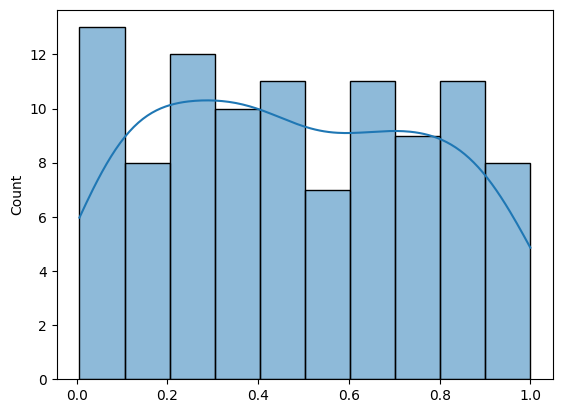

In [18]:
sns.histplot(distribution,kde=True,bins=10)

In [19]:
bin_edges

array([0.0061692 , 0.1055441 , 0.204919  , 0.3042939 , 0.4036688 ,
       0.50304365, 0.6024186 , 0.7017935 , 0.8011684 , 0.9005433 ,
       0.99991816], dtype=float32)

In [20]:
print(bin_edges[0] , bin_edges[-1])
bin_edges[0] = -float("inf")
bin_edges[-1] = float("inf")
print(bin_edges[0] , bin_edges[-1])

0.0061692 0.99991816
-inf inf


In [22]:
bin_edges

array([      -inf, 0.1055441 , 0.204919  , 0.3042939 , 0.4036688 ,
       0.50304365, 0.6024186 , 0.7017935 , 0.8011684 , 0.9005433 ,
              inf], dtype=float32)

In [23]:
np.digitize(distribution,bin_edges)

array([ 1,  3,  6,  5,  4,  9,  3,  5,  4,  1,  7,  4,  1,  3,  3,  9,  7,
        9,  1,  8,  1,  4,  9,  3,  5, 10,  8,  6,  1,  4,  2,  4,  2,  1,
        8,  2,  9,  2,  4,  1,  6, 10,  4,  7, 10,  5,  9,  3,  8,  5,  5,
        9,  3,  1,  7,  7,  3,  7,  5,  2,  5,  3,  7,  8,  9, 10,  8,  1,
       10,  7,  9,  7,  8,  6, 10,  8,  4,  7,  3,  7,  1,  1,  6,  9,  2,
        9,  6,  5,  8,  6,  5,  5,  2,  2,  4, 10, 10,  3,  1,  3])

In [28]:
bin_idx = np.digitize(distribution,bin_edges)

In [24]:
bin_edges.shape

(11,)

In [25]:
hist_smoothed_density = hist_density + 0.001
print(hist_density)
hist_smoothed_density = hist_smoothed_density / np.sum(hist_smoothed_density)
print(hist_smoothed_density)

[1.30817745 0.80503227 1.20754832 1.00629042 1.10691979 0.70440287
 1.10691946 0.90566138 1.10691946 0.80503233]
[0.12997021 0.08001985 0.11998013 0.1        0.10999011 0.07002974
 0.10999008 0.09000993 0.10999008 0.08001986]


In [26]:
np.sum(hist_smoothed_density)

np.float64(1.0000000000000002)

<Axes: ylabel='Count'>

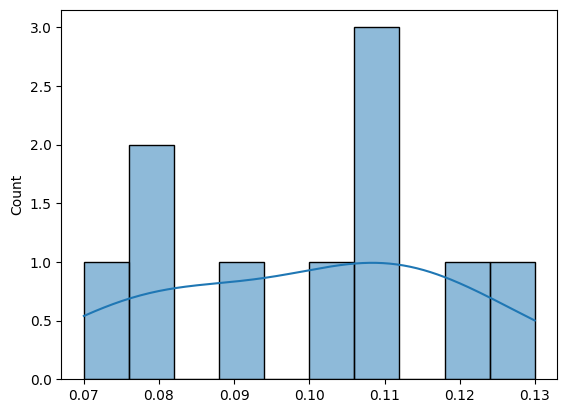

In [27]:
sns.histplot(hist_smoothed_density,kde=True,bins=10)

In [30]:
bin_idx - 1 # to make from 0 to 9

array([0, 2, 5, 4, 3, 8, 2, 4, 3, 0, 6, 3, 0, 2, 2, 8, 6, 8, 0, 7, 0, 3,
       8, 2, 4, 9, 7, 5, 0, 3, 1, 3, 1, 0, 7, 1, 8, 1, 3, 0, 5, 9, 3, 6,
       9, 4, 8, 2, 7, 4, 4, 8, 2, 0, 6, 6, 2, 6, 4, 1, 4, 2, 6, 7, 8, 9,
       7, 0, 9, 6, 8, 6, 7, 5, 9, 7, 3, 6, 2, 6, 0, 0, 5, 8, 1, 8, 5, 4,
       7, 5, 4, 4, 1, 1, 3, 9, 9, 2, 0, 2])

In [31]:
p = 1.0 / hist_smoothed_density[bin_idx-1]
p

array([ 7.69407064,  8.33471329, 14.27964668,  9.09172652,  9.99999957,
        9.09172924,  8.33471329,  9.09172652,  9.99999957,  7.69407064,
        9.09172924,  9.99999957,  7.69407064,  8.33471329,  8.33471329,
        9.09172924,  9.09172924,  9.09172924,  7.69407064, 11.10988514,
        7.69407064,  9.99999957,  9.09172924,  8.33471329,  9.09172652,
       12.49689785, 11.10988514, 14.27964668,  7.69407064,  9.99999957,
       12.49689879,  9.99999957, 12.49689879,  7.69407064, 11.10988514,
       12.49689879,  9.09172924, 12.49689879,  9.99999957,  7.69407064,
       14.27964668, 12.49689785,  9.99999957,  9.09172924, 12.49689785,
        9.09172652,  9.09172924,  8.33471329, 11.10988514,  9.09172652,
        9.09172652,  9.09172924,  8.33471329,  7.69407064,  9.09172924,
        9.09172924,  8.33471329,  9.09172924,  9.09172652, 12.49689879,
        9.09172652,  8.33471329,  9.09172924, 11.10988514,  9.09172924,
       12.49689785, 11.10988514,  7.69407064, 12.49689785,  9.09

In [32]:
assert p.shape == distribution.shape

In [34]:
p = p /np.sum(p)

<Axes: ylabel='Count'>

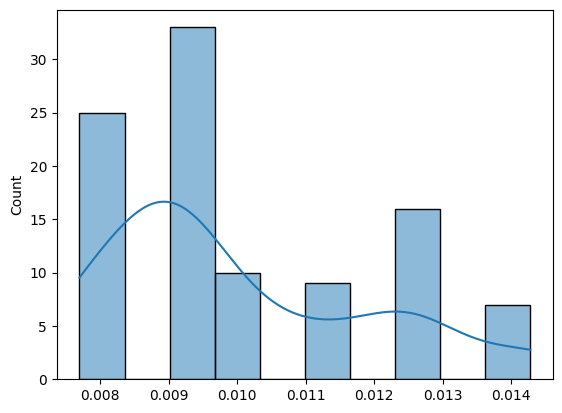

In [35]:
sns.histplot(p,kde=True,bins=10)